In [101]:
import random
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [102]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [103]:
len(words)

32033

In [104]:
# build the vocabulary of characters and mapping to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s, i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [105]:
# build the dataset

block_size = 3     # context length: how many characters do we take to predict the next one?
X, Y = [], []

for w in words:
    # print(w)
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        # print(''.join(itos[i] for i in context), '----->', itos[ix])
        context = context[1:] + [ix]

X = torch.tensor(X)
Y = torch.tensor(Y)


In [106]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

In [107]:
C = torch.randn((27, 2))
C

tensor([[ 0.1500,  0.3447],
        [ 0.4534,  0.1644],
        [-0.6972,  0.3308],
        [ 3.7189,  1.9837],
        [ 1.1770,  0.4651],
        [-0.3597,  0.6839],
        [-0.5804, -1.8125],
        [-0.2805, -0.6239],
        [-0.7942,  0.0938],
        [ 0.0723,  0.5694],
        [ 1.3298, -0.1648],
        [ 1.3244, -0.0536],
        [-0.3842, -1.1342],
        [ 0.1272, -0.3518],
        [-2.5102, -1.2352],
        [-0.1578,  0.3570],
        [-0.4662,  1.0069],
        [ 0.2448, -0.1422],
        [-0.0623,  0.2571],
        [-1.2796,  0.9302],
        [ 0.9613,  0.9802],
        [ 0.4160, -0.2288],
        [ 1.1252,  1.4163],
        [ 0.6819,  0.1258],
        [-0.7651, -0.1771],
        [-0.3472, -0.6645],
        [-1.0865,  0.2824]])

In [108]:
C[5]

tensor([-0.3597,  0.6839])

In [109]:
# F.one_hot(torch.tensor(5), num_classes=27).float() @ C         similar way to index C[5]

In [110]:
C[X].shape

torch.Size([228146, 3, 2])

In [111]:
X[1, 2]

tensor(5)

In [112]:
C[X][1, 2]

tensor([-0.3597,  0.6839])

In [113]:
C[5]

tensor([-0.3597,  0.6839])

In [114]:
embbed = C[X]

In [115]:
W1 = torch.randn((6, 100))   # 100 neurons, 6 inputs
b1 = torch.randn(100)

In [116]:
embbed @ W1 + b1

RuntimeError: mat1 and mat2 shapes cannot be multiplied (684438x2 and 6x100)

In [ ]:
a = embbed[:, 0, :]  # plucks out (32, 2) embbedings of the first word
a .shape

torch.Size([32, 2])

In [117]:
torch.cat([embbed[:, 0, :], embbed[:, 1, :], embbed[:, 2, :]], 1)

tensor([[ 0.1500,  0.3447,  0.1500,  0.3447,  0.1500,  0.3447],
        [ 0.1500,  0.3447,  0.1500,  0.3447, -0.3597,  0.6839],
        [ 0.1500,  0.3447, -0.3597,  0.6839,  0.1272, -0.3518],
        ...,
        [-1.0865,  0.2824, -1.0865,  0.2824, -0.3472, -0.6645],
        [-1.0865,  0.2824, -0.3472, -0.6645, -1.0865,  0.2824],
        [-0.3472, -0.6645, -1.0865,  0.2824, -0.7651, -0.1771]])

In [118]:
torch.cat(torch.unbind(embbed, 1), 1).shape  # a list of tensors concatonated 

torch.Size([228146, 6])

In [119]:
a = torch.arange(18)
a

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17])

In [120]:
a.view(3, 3, 2)   # view can interpret an array in different dimension, storage offsets, sides and shapes are manipulated

tensor([[[ 0,  1],
         [ 2,  3],
         [ 4,  5]],

        [[ 6,  7],
         [ 8,  9],
         [10, 11]],

        [[12, 13],
         [14, 15],
         [16, 17]]])

In [121]:
a.storage()

C:\Users\garva\AppData\Local\Temp\ipykernel_3224\214256462.py:1: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  a.storage()


 0
 1
 2
 3
 4
 5
 6
 7
 8
 9
 10
 11
 12
 13
 14
 15
 16
 17
[torch.storage.TypedStorage(dtype=torch.int64, device=cpu) of size 18]

In [122]:
embbed.view(32, 6)

RuntimeError: shape '[32, 6]' is invalid for input of size 1368876

In [ ]:
embbed.view(32, 6) == torch.cat(torch.unbind(embbed, 1), 1)   # same as before, another method

tensor([[True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, T

In [123]:
# can also do
h = torch.tanh(embbed.view(embbed.shape[0], 6) @ W1 + b1)         # instead of (32, 6) we can also do h = embbed.view(-1, 6) @ W1 + b1, Torch will automatically infer -1 as x * 6 = embbed.shape
h

tensor([[ 0.4171, -0.8146, -0.6808,  ...,  0.8363, -0.9704, -0.6239],
        [-0.0575, -0.4838, -0.9646,  ...,  0.1774, -0.9932, -0.7854],
        [-0.7672, -0.6874, -0.6114,  ...,  0.9683, -0.8815,  0.0523],
        ...,
        [-0.9918, -0.0586, -0.9570,  ...,  0.9975, -0.9424,  0.5372],
        [-0.8344,  0.8613, -0.9893,  ...,  0.9269, -0.9976,  0.1429],
        [-0.9998, -0.8393, -0.9981,  ...,  0.8487, -0.5450, -0.2076]])

In [124]:
# final layer

W2 = torch.randn((100, 27))
b2 = torch.randn(27)

In [125]:
logits = h @ W2 + b2
logits.shape

torch.Size([228146, 27])

In [126]:
logits

tensor([[ -9.4621,  13.0400,   0.7324,  ...,   3.1576, -13.6416,   3.5963],
        [-12.3233,  20.4190,   5.9491,  ...,   1.2479,  -9.2073,  -2.2047],
        [-10.3979,   9.6088,  -4.3424,  ...,   0.9295, -19.0895,   8.5953],
        ...,
        [-10.3761,  15.2052,  -8.9941,  ...,  -1.1661,  -6.3881,   9.0882],
        [ -1.9411,  19.0779,  -1.5634,  ...,  -0.9831,   4.7944,  -9.5558],
        [-14.4467,  18.0228,   2.9278,  ...,  -2.3463, -11.2260,  -6.3577]])

In [127]:
counts = logits.exp()

In [128]:
probs = counts/counts.sum(1, keepdims=True)

In [129]:
probs[0].sum()

tensor(1.0000)

In [130]:
loss = -probs[torch.arange(32), Y].log().mean()

IndexError: shape mismatch: indexing tensors could not be broadcast together with shapes [32], [228146]

In [ ]:
loss

tensor(15.6683)

In [ ]:
# --------------- SUMMARIZED -------------------

In [ ]:
Xtr.shape, Ytr.shape

(torch.Size([182625, 3]), torch.Size([182625]))

In [143]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [144]:
sum(p.nelement() for p in parameters)

11897

In [145]:
for p in parameters:
    p.requires_grad = True

In [131]:
# for getting optimal learning rate

In [132]:
lre = torch.linspace(-3, 0, 1000)  # 1000 numbers b/w -3 and 0
lrs = 10**lre                      # raise it to power of 10, so we get lowest 0.01 and highest 1

In [147]:
lri = []   # for tracking the learning rate-
lossi = [] # -w.r.t to the loss, loss associated with each learning rate
stepi = []

for i in range(30000):

    # minibatch contruct
    index = torch.randint(0, Xtr.shape[0], (32, )) # generating a tuple of numbers between 0 and X.shape[0]

    # forward pass
    emb = C[Xtr[index]] # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 30) @ W1 + b1)  # (32, 100)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Ytr[index])

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update
    #lr = lrs[i]
    for p in parameters:
        p.data += -0.1 * p.grad    # for finding optimal lr, use lr instead 0.1 
    
    # track stats for learning rate
    #lri.append(lre[i])
    lossi.append(loss.item())
    stepi.append(i)
print(loss.item())

2.1061437129974365


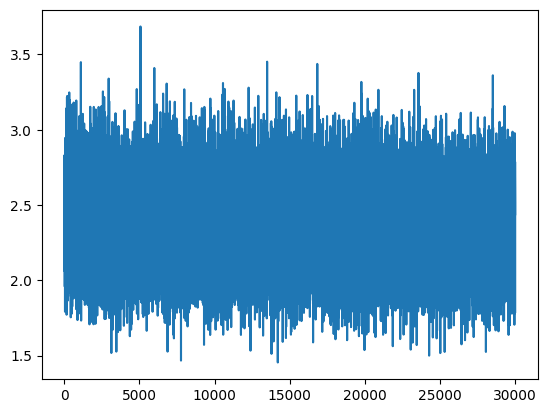

In [ ]:
plt.plot(stepi, lossi)

In [ ]:
# In mini batches quality of gradient is lower, it is not the exact gradient but rather an approximation. On the flip side, we can make much more steps, because it is faster.
# So, we the option of having perfect direction but less steps or okay-ish direction, but still good, and much more steps.

In [134]:
# loss of Dev set

In [135]:
emb = C[XDev] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)  # (32, 100)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, YDev)
print(loss.item())

RuntimeError: mat1 and mat2 shapes cannot be multiplied (4531x30 and 6x100)

In [ ]:
# loss of training set

In [136]:
emb = C[Xtr] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)  # (32, 100)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, Ytr)
print(loss.item())

RuntimeError: mat1 and mat2 shapes cannot be multiplied (36525x30 and 6x100)

In [137]:
# since both dev and training set losses are similar, we are ot overfitting, rather underfitting, and our model is quite small.

Text(0, 0.5, 'loss')

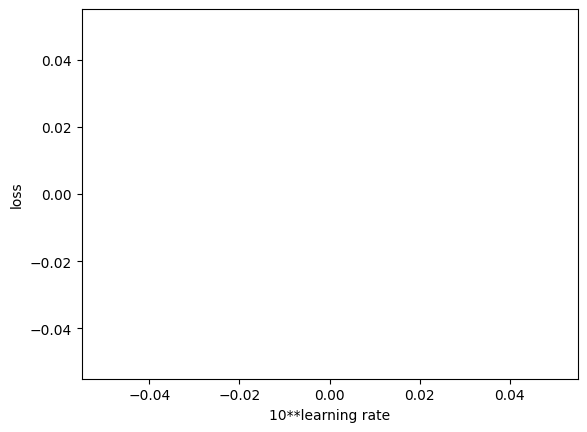

In [138]:
plt.plot(lri, lossi)
plt.xlabel("10**learning rate")
plt.ylabel("loss")

In [139]:
# so 10 ^ -1 = 0.1 is a good learning rate

In [140]:
# training split, dev/validation split, test split
# 80%, 10%, 10%
# parameters, hyperparameters, validate performance on test split
# could overfit if tested too many times

In [141]:
# build dataset for different splits

def build_dataset(words):
    block_size = 3       # context length: how many characters do we take to predict the next one?
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

random.seed(42)
random.shuffle(words)
n1 = int(0.8* len(words))
n2 = int(0.9* len(words))

Xtr, Ytr = build_dataset(words[:n1])
XDev, YDev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [148]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    out = []
    context = [0] * block_size
    while True:
        emb = C[torch.tensor([context])]   # (1, block_size, d) for single example
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break
    print("".join(itos[i] for i in out))

carpaviani.
hari.
kimla.
jehiyahnanden.
jazhunnalee.
ara.
areei.
jermari.
chaiivin.
jailyn.
brie.
caifen.
tis.
lileanianni.
jazeloniearini.
jacenciesdi.
edie.
jia.
gilee.
jarlyna.
